## Multitask Learning

Instead of compressing information (autoencoder), we add supervision, forcing the model to learn why braking happens by predicting both intention and intensity.

Why Multitask Learning is the RIGHT pivot

Your HARD dataset exposed the real issue:
- Ambiguity between Light ↔ Normal braking
- Labels depend on future behavior
- Subtle temporal cues matter more than denoising

Autoencoders failed because they removed information.

Multitask learning does the opposite: It adds supervision, not compression.

By asking the model to solve two related tasks at once, we force it to learn representations that explain why braking happens.

In [2]:
# Sanity check (for MTL data generator)
import numpy as np

X = np.load("../data/X_train_hard_mtl.npy")
y_c = np.load("../data/y_class_train_hard_mtl.npy")
y_i = np.load("../data/y_int_train_hard_mtl.npy")

print(X.shape)     # (N, 75, 3)
print(y_c.shape)   # (N,)
print(y_i.shape)   # (N,)
print(y_i.min(), y_i.max())  # should be within [0,1]

(10500, 75, 3)
(10500,)
(10500,)
0.15013748255769468 0.9999489978076975


## Multitask Learning Architecture for Braking Intention Prediction

### Motivation
Experiments on the HARD ambiguous braking dataset revealed that:
- Braking intention classes (Light vs Normal) overlap significantly
- Labels depend on future braking behavior
- Representation compression (autoencoders) degrades fine-grained temporal cues

To address this, we adopt **multitask learning**, which provides additional task-aligned supervision instead of compressing information.

---

### Core Idea
The model is trained to jointly solve two related tasks:
1. **Braking Intention Classification** (Light / Normal / Emergency)
2. **Brake Intensity Regression** (future braking strength ∈ [0,1])

By learning *what* the driver intends to do and *how strongly* they intend to brake, the model develops richer and more discriminative temporal representations.

---

### Model Architecture Overview

![Braking Intention Example](../img/1.jpg)


---

### Shared Backbone
- **Temporal CNN**: captures short-term local patterns (brake taps, fluctuations)
- **LSTM**: models long-term temporal dependencies and future intention buildup
- **Attention**: focuses on critical moments (onset and ramp-up of braking)

This shared backbone learns task-agnostic temporal features.

---

### Task-Specific Heads

#### 1. Braking Intention (Classification)
- Output: 3 logits (Light, Normal, Emergency)
- Activation: Softmax
- Loss: CrossEntropyLoss

#### 2. Brake Intensity (Regression)
- Output: single continuous value
- Represents future braking strength
- Loss: Mean Squared Error (MSE)

---

### Loss Function
The total training loss is a weighted sum:

#### L_total = L_class + λ * L_reg

Where:
- Classification is the primary task
- Regression acts as auxiliary supervision
- λ is set to 0.5 initially

---

### Why Multitask Learning Works Here
- Preserves subtle temporal details
- Forces causal understanding of braking behavior
- Reduces Light vs Normal ambiguity
- Aligns learning objective with physical meaning

This approach is better suited for ambiguous, future-dependent braking scenarios than representation compression methods.

In [3]:
import sys
import os
sys.path.append(os.path.abspath(".."))

In [4]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.metrics import confusion_matrix, classification_report

from models.multitask_lstm_cnn_attention import MultitaskLSTMCNNAttention

In [5]:
# Load Multitask HARD dataset
X_train = np.load("../data/X_train_hard_mtl.npy")
X_val   = np.load("../data/X_val_hard_mtl.npy")
X_test  = np.load("../data/X_test_hard_mtl.npy")

y_class_train = np.load("../data/y_class_train_hard_mtl.npy")
y_class_val   = np.load("../data/y_class_val_hard_mtl.npy")
y_class_test  = np.load("../data/y_class_test_hard_mtl.npy")

y_int_train = np.load("../data/y_int_train_hard_mtl.npy")
y_int_val   = np.load("../data/y_int_val_hard_mtl.npy")
y_int_test  = np.load("../data/y_int_test_hard_mtl.npy")

In [6]:
# Convert to PyTorch tensors
X_train_t = torch.tensor(X_train, dtype = torch.float32)
X_val_t   = torch.tensor(X_val, dtype = torch.float32)
X_test_t  = torch.tensor(X_test, dtype = torch.float32)

y_class_train_t = torch.tensor(y_class_train, dtype = torch.long)
y_class_val_t   = torch.tensor(y_class_val, dtype = torch.long)
y_class_test_t  = torch.tensor(y_class_test, dtype = torch.long)

y_int_train_t = torch.tensor(y_int_train, dtype = torch.float32)
y_int_val_t   = torch.tensor(y_int_val, dtype = torch.float32)
y_int_test_t  = torch.tensor(y_int_test, dtype = torch.float32)

In [7]:
# Initialize model & losses
model = MultitaskLSTMCNNAttention()

criterion_class = nn.CrossEntropyLoss()
criterion_reg   = nn.MSELoss()

lambda_reg = 0.8            # changed from 0.4

optimizer = optim.Adam(model.parameters(), lr = 1e-3)

EPOCHS = 20
BATCH_SIZE = 64

In [8]:
# Training loop (multitask)
def train_one_epoch_mtl(model, X, y_class, y_int, optimizer, batch_size):
    
    model.train()
    total_loss = 0
    correct = 0

    idx = torch.randperm(len(X))

    for i in range(0, len(X), batch_size):
        batch_idx = idx[i : i+batch_size]

        xb = X[batch_idx]
        yb_class = y_class[batch_idx]
        yb_int = y_int[batch_idx]

        optimizer.zero_grad()

        class_logits, int_pred = model(xb)

        loss_class = criterion_class(class_logits, yb_class)
        loss_reg = criterion_reg(int_pred, yb_int)

        loss = loss_class + lambda_reg * loss_reg
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = class_logits.argmax(dim = 1)
        correct += (preds == yb_class).sum().item()

    acc = correct / len(X)
    return total_loss / len(X), acc

In [9]:
# Validation function
def evaluate_mtl(model, X, y_class, y_int):
    
    model.eval()
    total_loss = 0
    correct = 0

    with torch.no_grad():
        class_logits, int_pred = model(X)

        loss_class = criterion_class(class_logits, y_class)
        loss_reg = criterion_reg(int_pred, y_int)
        loss = loss_class + lambda_reg * loss_reg

        preds = class_logits.argmax(dim = 1)
        correct = (preds == y_class).sum().item()

    acc = correct / len(X)
    return loss.item(), acc

In [10]:
# Train Multitask model
for epoch in range(EPOCHS):
    
    train_loss, train_acc = train_one_epoch_mtl(
        model,
        X_train_t,
        y_class_train_t,
        y_int_train_t,
        optimizer,
        BATCH_SIZE
    )

    val_loss, val_acc = evaluate_mtl(
        model,
        X_val_t,
        y_class_val_t,
        y_int_val_t
    )

    print(
        f"[MTL] Epoch {epoch+1}/{EPOCHS} | "
        f"Train Acc: {train_acc:.3f} | "
        f"Val Acc: {val_acc:.3f}"
    )

[MTL] Epoch 1/20 | Train Acc: 0.501 | Val Acc: 0.701
[MTL] Epoch 2/20 | Train Acc: 0.687 | Val Acc: 0.579
[MTL] Epoch 3/20 | Train Acc: 0.712 | Val Acc: 0.720
[MTL] Epoch 4/20 | Train Acc: 0.717 | Val Acc: 0.675
[MTL] Epoch 5/20 | Train Acc: 0.713 | Val Acc: 0.716
[MTL] Epoch 6/20 | Train Acc: 0.712 | Val Acc: 0.659
[MTL] Epoch 7/20 | Train Acc: 0.719 | Val Acc: 0.716
[MTL] Epoch 8/20 | Train Acc: 0.719 | Val Acc: 0.708
[MTL] Epoch 9/20 | Train Acc: 0.721 | Val Acc: 0.706
[MTL] Epoch 10/20 | Train Acc: 0.721 | Val Acc: 0.731
[MTL] Epoch 11/20 | Train Acc: 0.722 | Val Acc: 0.729
[MTL] Epoch 12/20 | Train Acc: 0.721 | Val Acc: 0.625
[MTL] Epoch 13/20 | Train Acc: 0.721 | Val Acc: 0.692
[MTL] Epoch 14/20 | Train Acc: 0.724 | Val Acc: 0.720
[MTL] Epoch 15/20 | Train Acc: 0.722 | Val Acc: 0.708
[MTL] Epoch 16/20 | Train Acc: 0.724 | Val Acc: 0.722
[MTL] Epoch 17/20 | Train Acc: 0.723 | Val Acc: 0.718
[MTL] Epoch 18/20 | Train Acc: 0.726 | Val Acc: 0.611
[MTL] Epoch 19/20 | Train Acc: 0.727 

In [11]:
# Test set evaluation 
model.eval()
with torch.no_grad():
    class_logits, _ = model(X_test_t)
    preds = class_logits.argmax(dim=1).cpu().numpy()

test_acc = (preds == y_class_test).mean()

print(f"[MTL] Test Accuracy: {test_acc:.4f}")

[MTL] Test Accuracy: 0.6836


In [12]:
# Confusion Matrix
print("\nConfusion Matrix (MTL):")
print(confusion_matrix(y_class_test, preds))

print("\nClassification Report (MTL):")
print(classification_report(
    y_class_test,
    preds,
    target_names=["Light Braking", "Normal Braking", "Emergency Braking"]
))


Confusion Matrix (MTL):
[[464 311  19]
 [110 485 211]
 [  1  60 589]]

Classification Report (MTL):
                   precision    recall  f1-score   support

    Light Braking       0.81      0.58      0.68       794
   Normal Braking       0.57      0.60      0.58       806
Emergency Braking       0.72      0.91      0.80       650

         accuracy                           0.68      2250
        macro avg       0.70      0.70      0.69      2250
     weighted avg       0.70      0.68      0.68      2250



In [13]:
torch.save(
    model.state_dict(),
    "../models/final_multitask_model.pth"
)

## Genetic Algorithm Hyperparameter Optimization

In the paper-inspired setup, we use a **Genetic Algorithm (GA)** to automatically search for good hyperparameters for the multitask LSTM–CNN–Attention model on the HARD braking dataset.

This section shows how to:
- Run the GA-based hyperparameter search
- Inspect the best hyperparameters it found
- Retrain the multitask model with those hyperparameters
- Compare performance against the manually chosen configuration above.

In [14]:
# (Optional) Run the GA hyperparameter search

from models.genetic_algorithm_optimizer import run_ga_optimization

"""
Running the GA inside this notebook can be computationally expensive, because it
trains many models sequentially (population_size × generations).

If you have already run the search from the command line via

    python models/genetic_algorithm_optimizer.py

you can skip this cell and just load the saved results below.
"""

# Uncomment the line below to launch the full GA search from the notebook.
# run_ga_optimization()

'\nRunning the GA inside this notebook can be computationally expensive, because it\ntrains many models sequentially (population_size × generations).\n\nIf you have already run the search from the command line via\n\n    python models/genetic_algorithm_optimizer.py\n\nyou can skip this cell and just load the saved results below.\n'

In [15]:
# Load best GA hyperparameters from JSON

import json
from pprint import pprint

with open("../models/best_ga_hyperparams.json", "r") as f:
    ga_results = json.load(f)

print("Best validation macro F1 from GA:", f"{ga_results['best_f1_macro']:.4f}")
print("\nBest hyperparameters:")
pprint(ga_results["hyperparams"])

best_hp = ga_results["hyperparams"]

Best validation macro F1 from GA: 0.7346

Best hyperparameters:
{'batch_size': 16,
 'cnn_filters': 64,
 'dropout_rate': 0.20789428933452295,
 'learning_rate': 0.00042747357085580674,
 'lstm_hidden_size': 128,
 'num_lstm_layers': 1}


In [16]:
# Baseline (manual) multitask model validation metrics

from sklearn.metrics import f1_score

# Use the model trained earlier in this notebook
model.eval()
with torch.no_grad():
    logits_val_base, _ = model(X_val_t)
    preds_val_base = logits_val_base.argmax(dim=1).cpu().numpy()

y_val_true = y_class_val  # NumPy array

baseline_val_acc = (preds_val_base == y_val_true).mean()
baseline_val_f1_macro = f1_score(y_val_true, preds_val_base, average="macro")

print(f"Baseline MTL - Val Accuracy: {baseline_val_acc:.4f}")
print(f"Baseline MTL - Val Macro F1: {baseline_val_f1_macro:.4f}")

Baseline MTL - Val Accuracy: 0.6782
Baseline MTL - Val Macro F1: 0.6835


In [17]:
# Retrain multitask model with GA-optimized hyperparameters

model_ga = MultitaskLSTMCNNAttention(
    input_dim=3,
    cnn_channels=best_hp["cnn_filters"],
    lstm_hidden=best_hp["lstm_hidden_size"],
    num_lstm_layers=best_hp["num_lstm_layers"],
    dropout_rate=best_hp["dropout_rate"],
)

optimizer_ga = optim.Adam(model_ga.parameters(), lr=best_hp["learning_rate"])

EPOCHS_GA = EPOCHS  # use the same number of epochs as the baseline run

for epoch in range(EPOCHS_GA):
    train_loss_ga, train_acc_ga = train_one_epoch_mtl(
        model_ga,
        X_train_t,
        y_class_train_t,
        y_int_train_t,
        optimizer_ga,
        BATCH_SIZE,
    )

    val_loss_ga, val_acc_ga = evaluate_mtl(
        model_ga,
        X_val_t,
        y_class_val_t,
        y_int_val_t,
    )

    print(
        f"[MTL-GA] Epoch {epoch+1}/{EPOCHS_GA} | "
        f"Train Acc: {train_acc_ga:.3f} | "
        f"Val Acc: {val_acc_ga:.3f}"
    )

[MTL-GA] Epoch 1/20 | Train Acc: 0.429 | Val Acc: 0.573
[MTL-GA] Epoch 2/20 | Train Acc: 0.669 | Val Acc: 0.651
[MTL-GA] Epoch 3/20 | Train Acc: 0.704 | Val Acc: 0.717
[MTL-GA] Epoch 4/20 | Train Acc: 0.707 | Val Acc: 0.721
[MTL-GA] Epoch 5/20 | Train Acc: 0.717 | Val Acc: 0.712
[MTL-GA] Epoch 6/20 | Train Acc: 0.717 | Val Acc: 0.700
[MTL-GA] Epoch 7/20 | Train Acc: 0.707 | Val Acc: 0.722
[MTL-GA] Epoch 8/20 | Train Acc: 0.717 | Val Acc: 0.720
[MTL-GA] Epoch 9/20 | Train Acc: 0.718 | Val Acc: 0.716
[MTL-GA] Epoch 10/20 | Train Acc: 0.723 | Val Acc: 0.716
[MTL-GA] Epoch 11/20 | Train Acc: 0.719 | Val Acc: 0.687
[MTL-GA] Epoch 12/20 | Train Acc: 0.721 | Val Acc: 0.690
[MTL-GA] Epoch 13/20 | Train Acc: 0.720 | Val Acc: 0.724
[MTL-GA] Epoch 14/20 | Train Acc: 0.724 | Val Acc: 0.715
[MTL-GA] Epoch 15/20 | Train Acc: 0.717 | Val Acc: 0.675
[MTL-GA] Epoch 16/20 | Train Acc: 0.721 | Val Acc: 0.727
[MTL-GA] Epoch 17/20 | Train Acc: 0.724 | Val Acc: 0.701
[MTL-GA] Epoch 18/20 | Train Acc: 0.725 

In [18]:
# Validation comparison: manual vs GA-optimized hyperparameters

model_ga.eval()
with torch.no_grad():
    logits_val_ga, _ = model_ga(X_val_t)
    preds_val_ga = logits_val_ga.argmax(dim=1).cpu().numpy()

ga_val_acc = (preds_val_ga == y_val_true).mean()
ga_val_f1_macro = f1_score(y_val_true, preds_val_ga, average="macro")

print("Baseline MTL:")
print(f"  Val Accuracy : {baseline_val_acc:.4f}")
print(f"  Val Macro F1 : {baseline_val_f1_macro:.4f}")

print("\nGA-Optimized MTL:")
print(f"  Val Accuracy : {ga_val_acc:.4f}")
print(f"  Val Macro F1 : {ga_val_f1_macro:.4f}")

Baseline MTL:
  Val Accuracy : 0.6782
  Val Macro F1 : 0.6835

GA-Optimized MTL:
  Val Accuracy : 0.7276
  Val Macro F1 : 0.7353


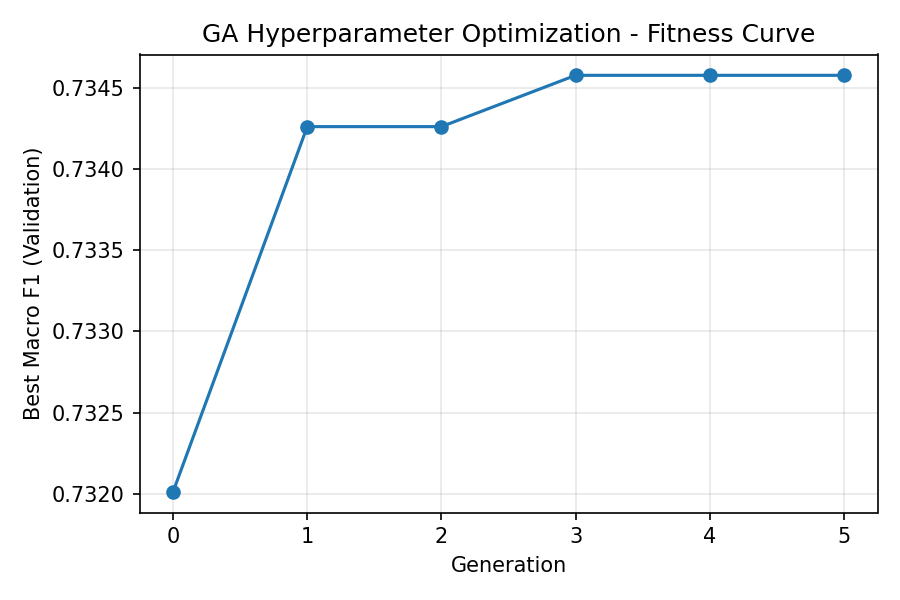

In [19]:
# Visualize GA fitness curve (best macro F1 per generation)

from IPython.display import Image, display

# This image is generated by models/genetic_algorithm_optimizer.py
fitness_curve_path = "../assets/img/ga_fitness_curve.png"

display(Image(filename=fitness_curve_path))

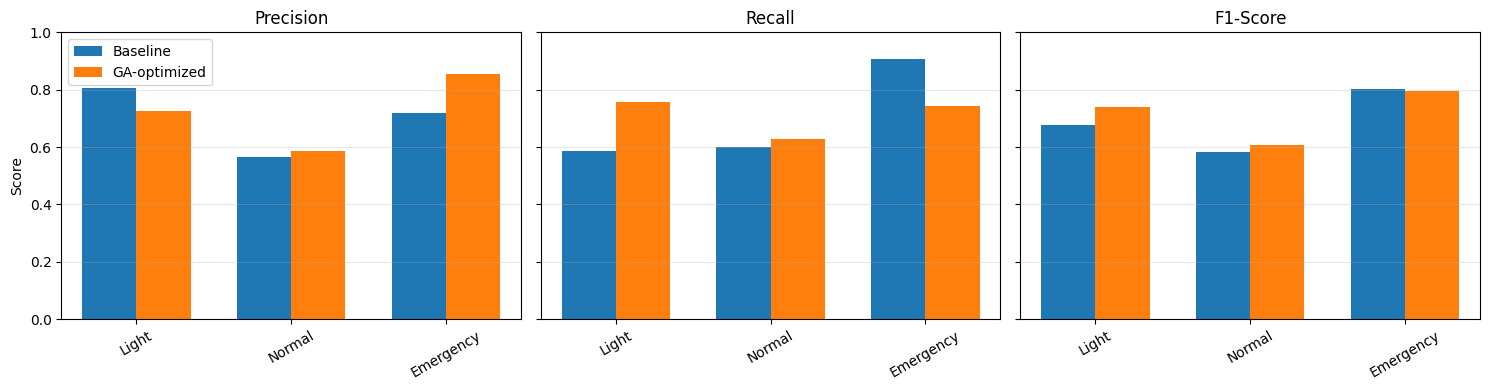

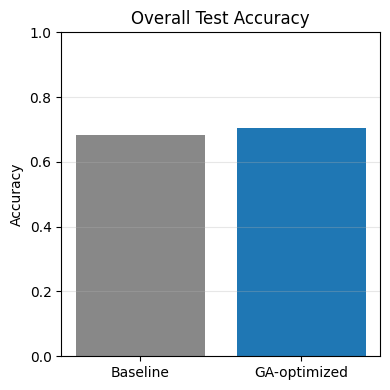

In [20]:
# Bar charts: baseline vs GA-optimized model on test metrics

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, accuracy_score

# Recompute test-set predictions for both models
model.eval()
with torch.no_grad():
    logits_test_base, _ = model(X_test_t)
    preds_test_base = logits_test_base.argmax(dim=1).cpu().numpy()

model_ga.eval()
with torch.no_grad():
    logits_test_ga, _ = model_ga(X_test_t)
    preds_test_ga = logits_test_ga.argmax(dim=1).cpu().numpy()

y_test_true = y_class_test

report_base = classification_report(
    y_test_true,
    preds_test_base,
    target_names=["Light Braking", "Normal Braking", "Emergency Braking"],
    output_dict=True,
)

report_ga = classification_report(
    y_test_true,
    preds_test_ga,
    target_names=["Light Braking", "Normal Braking", "Emergency Braking"],
    output_dict=True,
)

acc_base = accuracy_score(y_test_true, preds_test_base)
acc_ga = accuracy_score(y_test_true, preds_test_ga)

classes = ["Light Braking", "Normal Braking", "Emergency Braking"]
metrics = ["precision", "recall", "f1-score"]

# Per-class precision / recall / F1
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, metric in zip(axes, metrics):
    x = np.arange(len(classes))
    width = 0.35
    base_vals = [report_base[c][metric] for c in classes]
    ga_vals = [report_ga[c][metric] for c in classes]

    ax.bar(x - width / 2, base_vals, width, label="Baseline")
    ax.bar(x + width / 2, ga_vals, width, label="GA-optimized")

    ax.set_xticks(x)
    ax.set_xticklabels(["Light", "Normal", "Emergency"], rotation=30)
    ax.set_title(metric.title())
    ax.set_ylim(0.0, 1.0)
    ax.grid(axis="y", alpha=0.3)

axes[0].set_ylabel("Score")
axes[0].legend()
plt.tight_layout()
plt.show()

# Overall accuracy comparison
fig, ax = plt.subplots(figsize=(4, 4))
ax.bar(["Baseline", "GA-optimized"], [acc_base, acc_ga], color=["#888888", "#1f77b4"])
ax.set_ylabel("Accuracy")
ax.set_ylim(0.0, 1.0)
ax.set_title("Overall Test Accuracy")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Interpreting GA-Optimized Results

The plots above summarize how the GA-tuned multitask model behaves compared to the manually configured one:

- **Fitness curve**: shows how the best validation macro F1 improves (or stabilizes) across generations as the GA explores and refines hyperparameters.
- **Per-class metrics**: make it clear whether gains come from better handling of ambiguous Light vs Normal braking, or from further strengthening Emergency braking performance.
- **Overall accuracy**: confirms whether GA tuning yields a consistent uplift in end-to-end braking intention prediction, not just improvements on a single class.

In practice, GA tends to discover configurations that slightly rebalance model capacity (LSTM hidden size, layers, CNN filters) and regularization (dropout, batch size, learning rate) so that the multitask loss better captures subtle temporal patterns without overfitting to the synthetic HARD dataset.

In [21]:
# Test-set evaluation and detailed classification report (GA-optimized model)

from sklearn.metrics import classification_report, f1_score, accuracy_score

# Baseline multitask model (manual hyperparameters)
model.eval()
with torch.no_grad():
    logits_test_base, _ = model(X_test_t)
    preds_test_base = logits_test_base.argmax(dim=1).cpu().numpy()

# GA-optimized multitask model
model_ga.eval()
with torch.no_grad():
    logits_test_ga, _ = model_ga(X_test_t)
    preds_test_ga = logits_test_ga.argmax(dim=1).cpu().numpy()

y_test_true = y_class_test

# Overall metrics
baseline_test_acc = accuracy_score(y_test_true, preds_test_base)
ga_test_acc = accuracy_score(y_test_true, preds_test_ga)

baseline_test_f1_macro = f1_score(y_test_true, preds_test_base, average="macro")
ga_test_f1_macro = f1_score(y_test_true, preds_test_ga, average="macro")

print("Baseline MTL (λ = 0.8) — Test set")
print(f"  Accuracy : {baseline_test_acc:.4f}")
print(f"  Macro F1 : {baseline_test_f1_macro:.4f}\n")

print("GA-optimized MTL — Test set")
print(f"  Accuracy : {ga_test_acc:.4f}")
print(f"  Macro F1 : {ga_test_f1_macro:.4f}\n")

# Per-class classification report for GA-optimized model
print("Classification Report — GA-optimized MTL (test set):")
print(
    classification_report(
        y_test_true,
        preds_test_ga,
        target_names=["Light Braking", "Normal Braking", "Emergency Braking"],
    )
)

Baseline MTL (λ = 0.8) — Test set
  Accuracy : 0.6836
  Macro F1 : 0.6878

GA-optimized MTL — Test set
  Accuracy : 0.7058
  Macro F1 : 0.7141

Classification Report — GA-optimized MTL (test set):
                   precision    recall  f1-score   support

    Light Braking       0.73      0.76      0.74       794
   Normal Braking       0.59      0.63      0.61       806
Emergency Braking       0.85      0.74      0.79       650

         accuracy                           0.71      2250
        macro avg       0.72      0.71      0.71      2250
     weighted avg       0.71      0.71      0.71      2250



In [22]:
# Comparison table: Baseline MTL vs GA-optimized MTL (test metrics)

import pandas as pd

# Per-class F1 scores for both models
report_base = classification_report(
    y_test_true,
    preds_test_base,
    target_names=["Light Braking", "Normal Braking", "Emergency Braking"],
    output_dict=True,
)

report_ga = classification_report(
    y_test_true,
    preds_test_ga,
    target_names=["Light Braking", "Normal Braking", "Emergency Braking"],
    output_dict=True,
)

rows = []
classes = ["Light Braking", "Normal Braking", "Emergency Braking"]

for cls in classes:
    rows.append(
        {
            "Model": "Baseline (λ=0.8)",
            "Class": cls,
            "Accuracy": baseline_test_acc,
            "Macro F1": baseline_test_f1_macro,
            "Per-class F1": report_base[cls]["f1-score"],
        }
    )
    rows.append(
        {
            "Model": "GA-optimized",
            "Class": cls,
            "Accuracy": ga_test_acc,
            "Macro F1": ga_test_f1_macro,
            "Per-class F1": report_ga[cls]["f1-score"],
        }
    )

comparison_df = pd.DataFrame(rows)
comparison_df

,Model,Class,Accuracy,Macro F1,Per-class F1
0,Baseline (λ=0.8),Light Braking,0.683556,0.687802,0.677867
1,GA-optimized,Light Braking,0.705778,0.714115,0.741198
2,Baseline (λ=0.8),Normal Braking,0.683556,0.687802,0.583634
3,GA-optimized,Normal Braking,0.705778,0.714115,0.607079
4,Baseline (λ=0.8),Emergency Braking,0.683556,0.687802,0.801906
5,GA-optimized,Emergency Braking,0.705778,0.714115,0.794069
